# * Forex Gold  📈 XAUUSDT 🚀 LSTM

# Project Description

## Table of Contents:

1. [About Dataset](#about-dataset)
2. [Import Libraries & Dataset](#import-libraries--dataset)
3. [Overview & EDA Dataset](#Overview & EDA Dataset)
3. [Preparing Dataset](#Preparing-dataset)
4. [Predict Next 10 Days](#Predict Next 10 Days)



<a id="about-dataset"></a>
<div style="background-color: #800080; padding: 10px; border-radius: 20px; text-align: center; color: white; font-size: 30px;">
  <strong>1.About Dataset</strong>
</div>



**This project uses XAUUSDT dataset for the period 2018 to 2024. This data is recorded in a daily timeframe and information such as open close high low and volume is located inside it. There is also a percentage change in price in this dataset. In this project, I intend to use a variety of pricing information. Indicators such as SMA and Bollinger Bands.**

Predicting currencies and financial markets is crucial for traders, investors, and policymakers. Let’s explore why using Long Short-Term Memory (LSTM) models is significant in this context:

Crypto and Forex Market Complexities:

The foreign exchange (Forex) market is unique, with high risks and high profit opportunities. Traders can profit by predicting the direction of exchange rates between two currencies.

Incorrect predictions in Forex can lead to substantial losses, making it different from other typical time-series forecasting problems.

LSTM for Directional Prediction:
LSTM, a popular deep learning tool, has proven effective in various time-series forecasting problems..

Traders can profit from correct directional predictions and suffer losses from incorrect ones.

LSTM models can capture complex patterns and dependencies in historical data, aiding accurate directional predictions.

Data Sets Used:

Two main techniques in financial analysis are fundamental and technical analysis.

Fundamental analysis uses macroeconomic factors, while technical analysis relies on historical data.

LSTM models can incorporate both types of data:

Macroeconomic data: Includes factors like interest rates, GDP growth, and inflation.

Technical indicator data: Includes historical price movements, trading volumes, and other market-specific metrics.

A hybrid LSTM model combining these data sets has shown success in real-world experiments.

Advantages of LSTM and Pytorch:

LSTM models handle long sequences and capture temporal dependencies.

They can learn from historical patterns, adapt to changing market conditions, and make informed predictions.

LSTM’s ability to process sequential data makes it suitable for Forex forecasting.

PyTorch provides a flexible and efficient framework for building and training LSTM models.

In summary, predicting currencies and finance with LSTM models enhances decision-making, risk management, and profitability in the dynamic world of Forex trading. These models empower traders to make informed choices based on historical data and market trends.

<a id="#import-libraries--dataset"></a>
<div style="background-color: #800080; padding: 10px; border-radius: 20px; text-align: center; color: white; font-size: 30px;">
  <strong>2.Import Libraries & Dataset</strong>
</div>

In [1]:
!pip install yfinance


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 29.7 MB/s eta 0:00:00
  Installing build dependencies ... - \ | / - done
  Getting requirements to build wheel ... - done
  Preparing metadata (pyproject.toml) ... - done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 5.6 MB/s eta 0:00:00
  Created wheel for peewee: filename=peewee-3.17.6-cp310-cp310-linux_x86_64.whl size=275728 sha256=a4ac9023770011ea669c9994158a3f293297c4a17b88186918bcb5aca2d4f6a5
  Stored in directory: /root/.cache/pip/wheels/4b/b9/b0/83d6e258e8f963f5ff111a2cd8c483ca59372a86e6a2535212
Successfully built peewee


In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


In [3]:
# Download gold data
gold_data = yf.download('GC=F', start='2010-01-01', end='2024-10-01')

# Basic EDA
print(gold_data.head())
print(gold_data.info())
print(gold_data.describe())


[*********************100%***********************]  1 of 1 completed

                   Open         High          Low        Close    Adj Close  \
Date                                                                          
2010-01-04  1117.699951  1122.300049  1097.099976  1117.699951  1117.699951   
2010-01-05  1118.099976  1126.500000  1115.000000  1118.099976  1118.099976   
2010-01-06  1135.900024  1139.199951  1120.699951  1135.900024  1135.900024   
2010-01-07  1133.099976  1133.099976  1129.199951  1133.099976  1133.099976   
2010-01-08  1138.199951  1138.199951  1122.699951  1138.199951  1138.199951   

            Volume  
Date                
2010-01-04     184  
2010-01-05      53  
2010-01-06     363  
2010-01-07      56  
2010-01-08      54  
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3707 entries, 2010-01-04 to 2024-09-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       3707 non-null   float64
 1   High       3707 non-null   float64
 2   Low       

<a id="#Overview & EDA Dataset"></a>
<div style="background-color: #800080; padding: 10px; border-radius: 20px; text-align: center; color: white; font-size: 30px;">
  <strong>3.Overview & EDA Dataset</strong>
</div>

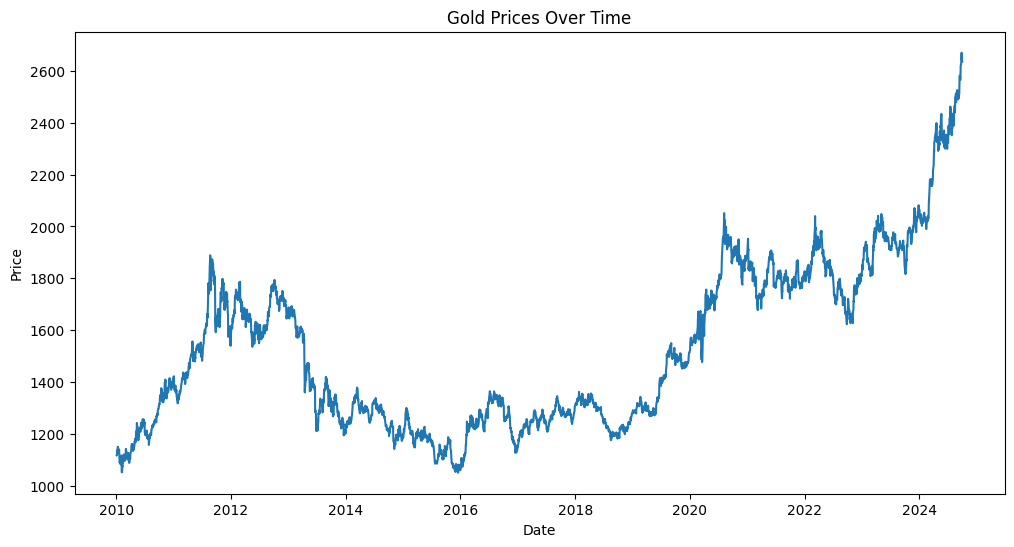

In [4]:
# Plotting closing prices
plt.figure(figsize=(12, 6))
plt.plot(gold_data.index, gold_data['Close'])
plt.title('Gold Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

# Missing values

In [5]:
# Check for missing values
print(gold_data.isnull().sum())

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [6]:
# Check for missing values
print(gold_data.isnull().sum())

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


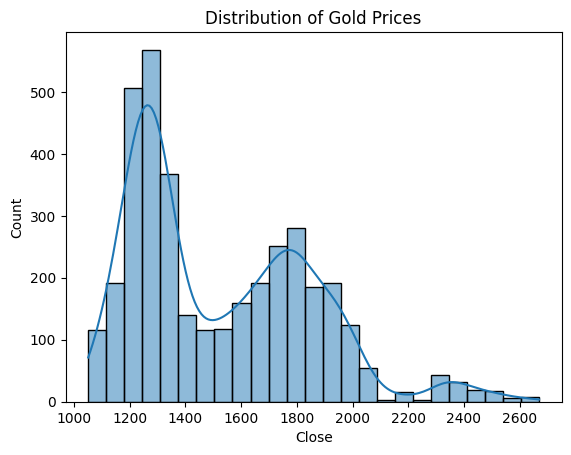

In [7]:
# Distribution of Close prices
sns.histplot(gold_data['Close'], kde=True)
plt.title('Distribution of Gold Prices')
plt.show()

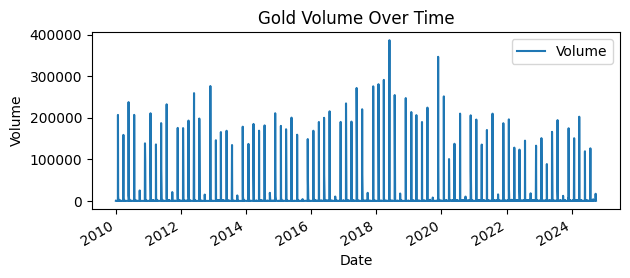

In [8]:
#  Adding Volume if available
if 'Volume' in gold_data.columns:
    plt.subplot(2, 1, 2)
    gold_data['Volume'].plot(label='Volume')
    plt.title('Gold Volume Over Time')
    plt.xlabel('Date')
    plt.ylabel('Volume')
    plt.legend()

plt.tight_layout()
plt.show()

In [9]:
# Assuming gold_data is your original daily data
daily_data = gold_data[['Open', 'High', 'Low', 'Close']]

# Create weekly data
weekly_data = gold_data.resample('W').agg({
    'Open': 'first', 
    'High': 'max', 
    'Low': 'min', 
    'Close': 'last'
})

# Create monthly data
monthly_data = gold_data.resample('ME').agg({
    'Open': 'first', 
    'High': 'max', 
    'Low': 'min', 
    'Close': 'last'
})

Daily Data Analysis
------------------
              Open         High          Low        Close
count  3707.000000  3707.000000  3707.000000  3707.000000
mean   1525.750175  1533.343054  1517.807230  1525.693822
std     321.746842   323.676002   320.116156   321.917326
min    1052.199951  1062.000000  1045.199951  1050.800049
25%    1258.099976  1264.350037  1253.000000  1257.450012
50%    1418.699951  1425.699951  1412.000000  1419.599976
75%    1776.950012  1786.250000  1768.299988  1775.800049
max    2670.000000  2672.100098  2660.800049  2669.899902


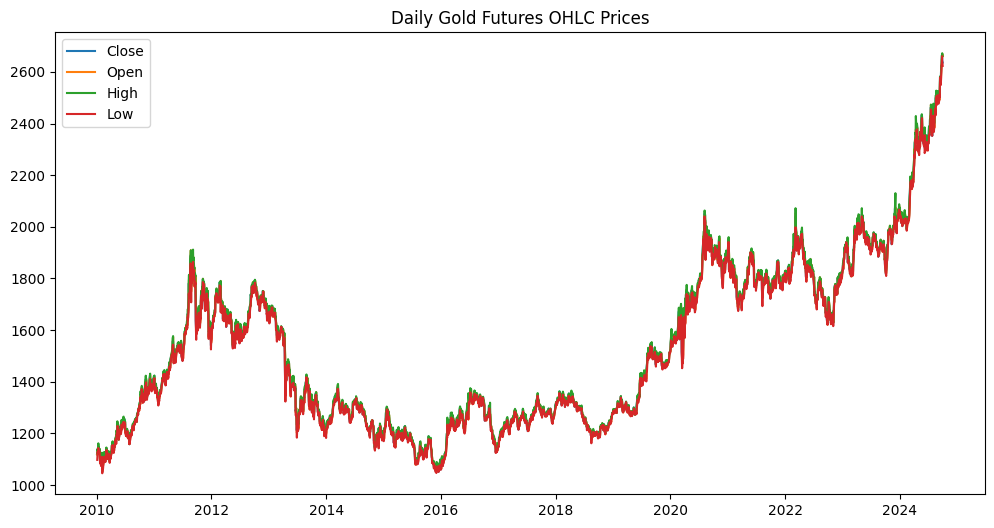

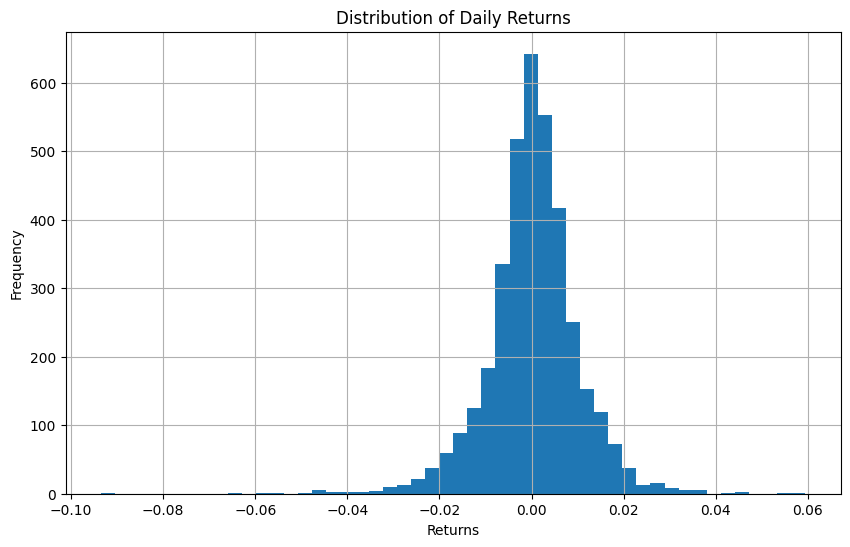

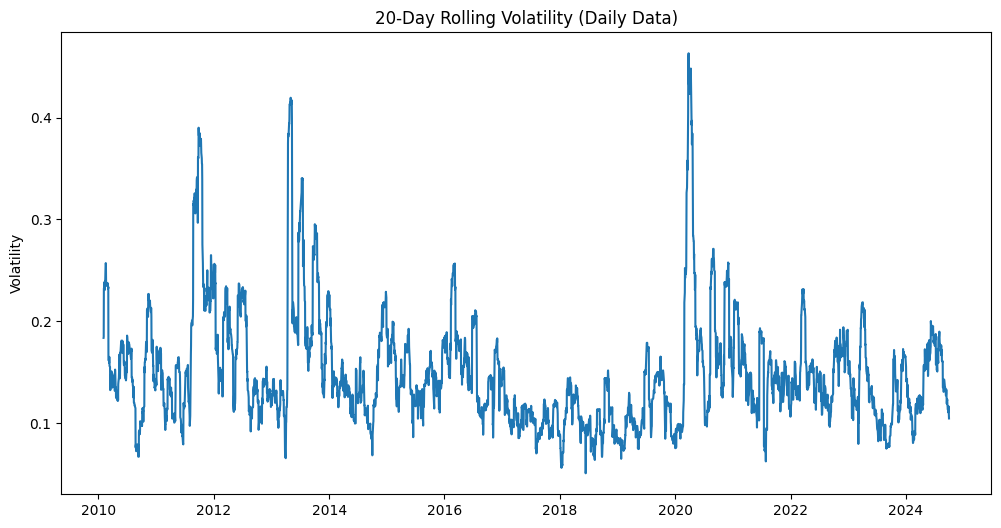

In [10]:
print("Daily Data Analysis")
print("------------------")
print(daily_data.describe())

# Plot daily OHLC
plt.figure(figsize=(12,6))
plt.plot(daily_data.index, daily_data['Close'], label='Close')
plt.plot(daily_data.index, daily_data['Open'], label='Open')
plt.plot(daily_data.index, daily_data['High'], label='High')
plt.plot(daily_data.index, daily_data['Low'], label='Low')
plt.title('Daily Gold Futures OHLC Prices')
plt.legend()
plt.show()

# Calculate daily returns
daily_returns = daily_data['Close'].pct_change()

plt.figure(figsize=(10,6))
daily_returns.hist(bins=50)
plt.title('Distribution of Daily Returns')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.show()

# Calculate daily volatility (20-day rolling window)
daily_volatility = daily_returns.rolling(window=20).std() * (252**0.5)

plt.figure(figsize=(12,6))
plt.plot(daily_data.index, daily_volatility)
plt.title('20-Day Rolling Volatility (Daily Data)')
plt.ylabel('Volatility')
plt.show()


Weekly Data Analysis
------------------
              Open         High          Low        Close
count   770.000000   770.000000   770.000000   770.000000
mean   1526.981171  1548.797534  1504.890261  1527.670520
std     323.276173   329.375487   319.102547   325.059997
min    1056.500000  1078.699951  1045.199951  1052.199951
25%    1258.324951  1275.200012  1241.575012  1257.474976
50%    1417.599976  1442.349976  1402.350037  1421.299988
75%    1778.000000  1799.675018  1753.750031  1776.399994
max    2660.899902  2672.100098  2625.500000  2644.300049


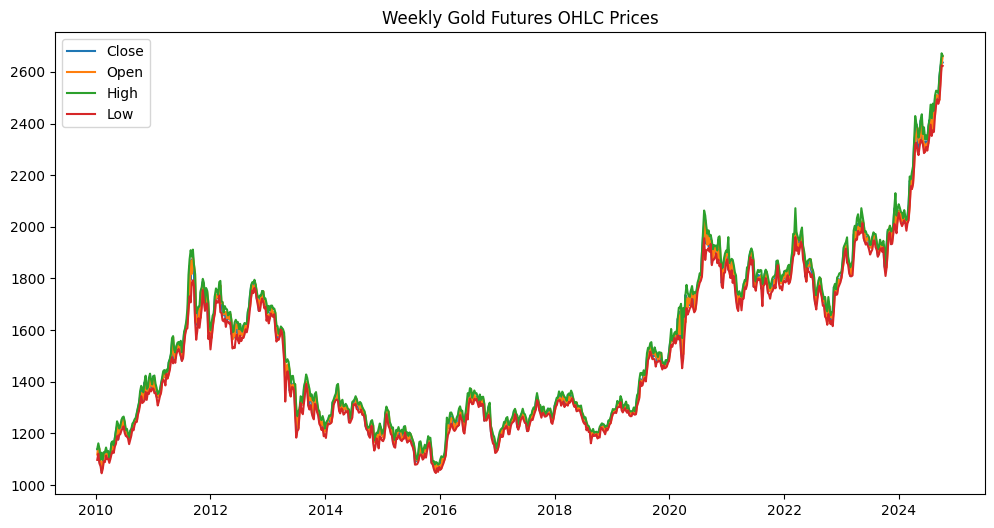

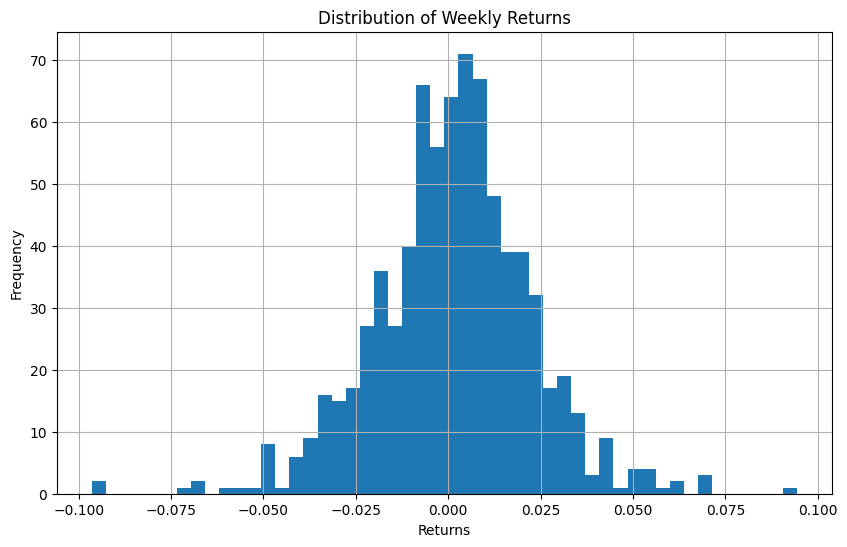

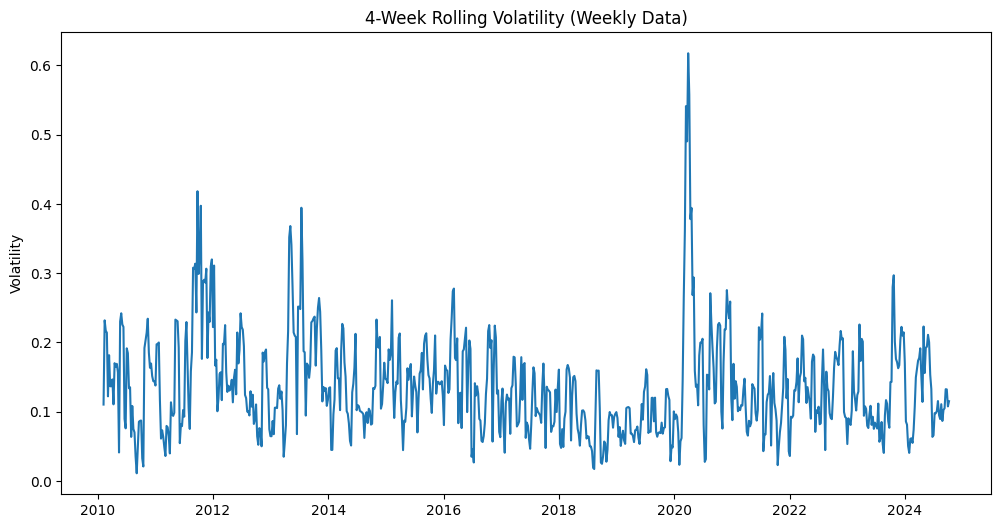

In [11]:
print("\nWeekly Data Analysis")
print("------------------")
print(weekly_data.describe())

# Plot weekly OHLC
plt.figure(figsize=(12,6))
plt.plot(weekly_data.index, weekly_data['Close'], label='Close')
plt.plot(weekly_data.index, weekly_data['Open'], label='Open')
plt.plot(weekly_data.index, weekly_data['High'], label='High')
plt.plot(weekly_data.index, weekly_data['Low'], label='Low')
plt.title('Weekly Gold Futures OHLC Prices')
plt.legend()
plt.show()

# Calculate weekly returns
weekly_returns = weekly_data['Close'].pct_change()

plt.figure(figsize=(10,6))
weekly_returns.hist(bins=50)
plt.title('Distribution of Weekly Returns')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.show()

# Calculate weekly volatility (4-week rolling window)
weekly_volatility = weekly_returns.rolling(window=4).std() * (52**0.5)

plt.figure(figsize=(12,6))
plt.plot(weekly_data.index, weekly_volatility)
plt.title('4-Week Rolling Volatility (Weekly Data)')
plt.ylabel('Volatility')
plt.show()


Monthly Data Analysis
------------------
              Open         High          Low        Close
count   177.000000   177.000000   177.000000   177.000000
mean   1518.687571  1576.064975  1473.117516  1526.567232
std     317.334770   335.281519   309.426915   326.053829
min    1063.400024  1098.800049  1045.199951  1060.300049
25%    1251.400024  1303.500000  1211.699951  1266.099976
50%    1415.300049  1446.900024  1362.500000  1426.099976
75%    1768.699951  1826.300049  1706.400024  1770.800049
max    2501.600098  2672.100098  2476.300049  2636.100098


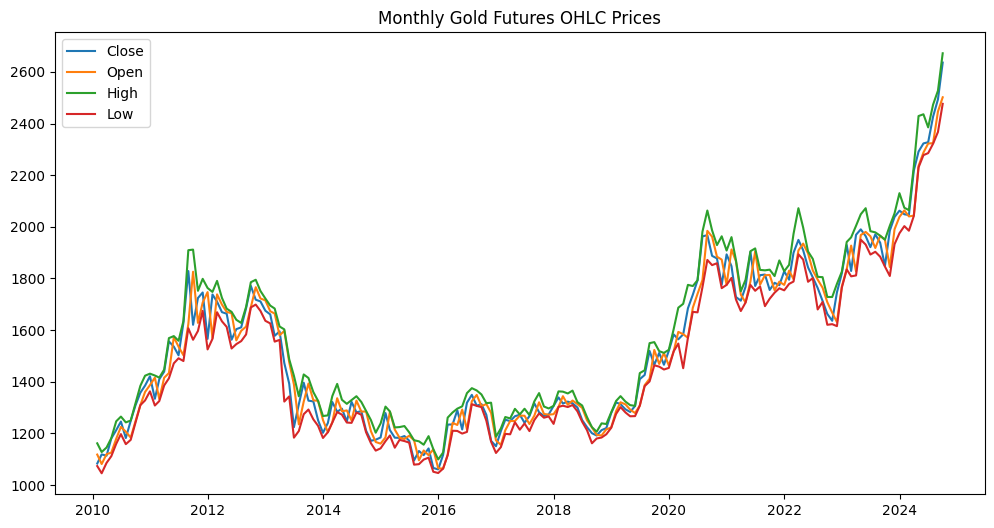

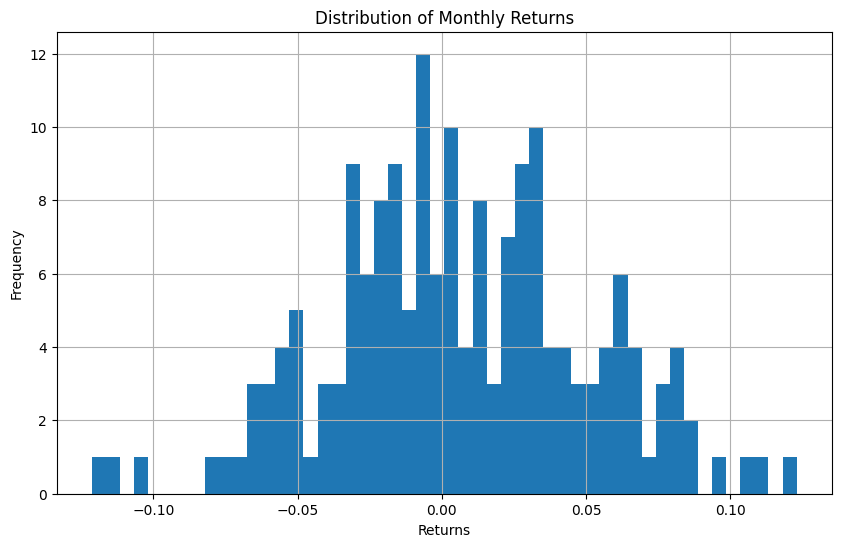

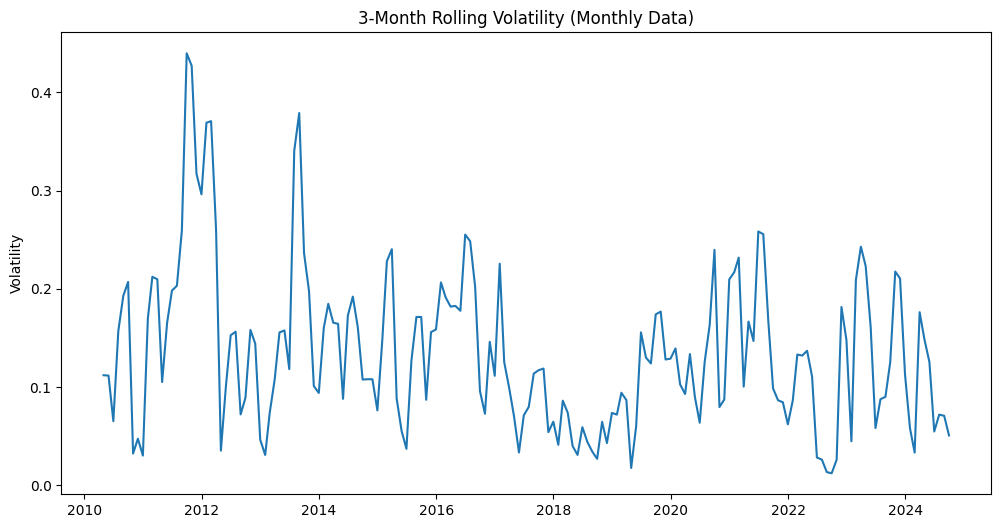

In [12]:
print("\nMonthly Data Analysis")
print("------------------")
print(monthly_data.describe())

# Plot monthly OHLC
plt.figure(figsize=(12,6))
plt.plot(monthly_data.index, monthly_data['Close'], label='Close')
plt.plot(monthly_data.index, monthly_data['Open'], label='Open')
plt.plot(monthly_data.index, monthly_data['High'], label='High')
plt.plot(monthly_data.index, monthly_data['Low'], label='Low')
plt.title('Monthly Gold Futures OHLC Prices')
plt.legend()
plt.show()

# Calculate monthly returns
monthly_returns = monthly_data['Close'].pct_change()

plt.figure(figsize=(10,6))
monthly_returns.hist(bins=50)
plt.title('Distribution of Monthly Returns')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.show()

# Calculate monthly volatility (3-month rolling window)
monthly_volatility = monthly_returns.rolling(window=3).std() * (12**0.5)

plt.figure(figsize=(12,6))
plt.plot(monthly_data.index, monthly_volatility)
plt.title('3-Month Rolling Volatility (Monthly Data)')
plt.ylabel('Volatility')
plt.show()


Average Returns Comparison
Daily: 0.00028208267183035644
Weekly: 0.0013203395157053563
Monthly: 0.006036945525391477

Average Volatility Comparison
Daily: 0.14942321270747957
Weekly: 0.1369376509104498
Monthly: 0.1349893255850891


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


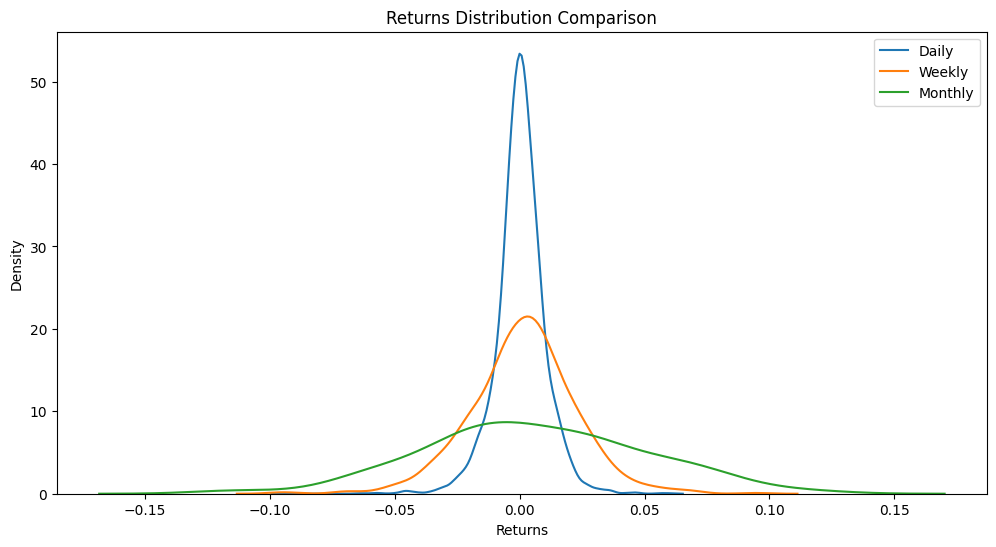

In [13]:
# Compare average returns
print("\nAverage Returns Comparison")
print("Daily:", daily_returns.mean())
print("Weekly:", weekly_returns.mean())
print("Monthly:", monthly_returns.mean())

# Compare volatility
print("\nAverage Volatility Comparison")
print("Daily:", daily_volatility.mean())
print("Weekly:", weekly_volatility.mean())
print("Monthly:", monthly_volatility.mean())

# Plot returns distribution comparison
plt.figure(figsize=(12,6))
sns.kdeplot(daily_returns.dropna(), label='Daily')
sns.kdeplot(weekly_returns.dropna(), label='Weekly')
sns.kdeplot(monthly_returns.dropna(), label='Monthly')
plt.title('Returns Distribution Comparison')
plt.xlabel('Returns')
plt.legend()
plt.show()

<a id="#preparing Dataset"></a>
<div style="background-color: #800080; padding: 10px; border-radius: 20px; text-align: center; color: white; font-size: 30px;">
  <strong>4. Preparing Dataset</strong>
</div>

In [14]:
# Scaling the data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(gold_data['Close'].values.reshape(-1,1))

# Create training and testing datasets
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 60
X_train, y_train = create_sequences(train_data, seq_length)
X_test, y_test = create_sequences(test_data, seq_length)


<div style="background-color: #800080; padding: 10px; border-radius: 20px; text-align: center; color: white; font-size: 30px;">
  <strong>5. Build, Train & Test Models</strong>
</div>

In [15]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping

# Build the LSTM model
model = Sequential()

# Add LSTM layers with dropout
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Add a dense output layer
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop])



/opt/conda/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0080 - val_loss: 7.5544e-04
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0012 - val_loss: 0.0016
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0010 - val_loss: 7.4010e-04
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.2514e-04 - val_loss: 6.5025e-04
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.1391e-04 - val_loss: 5.9894e-04
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.8829e-04 - val_loss: 9.1011e-04
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.9651e-04 - val_loss: 0.0014
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.6784e-04 - val_loss: 0.0012
Epoch 9/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.2043e-04 - val_loss: 4.3910e-04
Epoch 10/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.7969e-04 - val_loss: 8.3140e-04
Epoch 11/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.9456e-04 - val_loss: 4.8794e-04
Epoch 12/

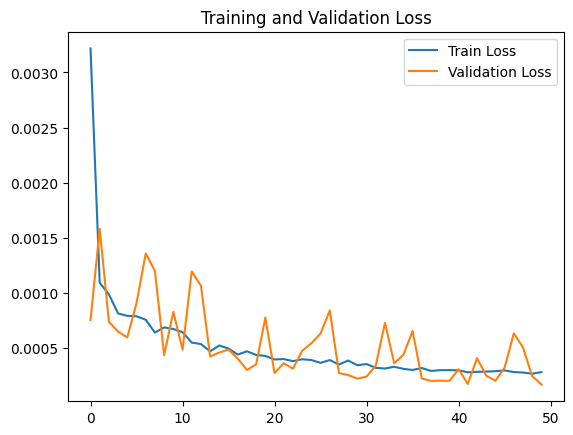

Epoch 1/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0130
Epoch 2/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0010
Epoch 3/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.8258e-04
Epoch 4/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.0600e-04
Epoch 5/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.8640e-04
Epoch 6/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.1758e-04
Epoch 7/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.4468e-04
Epoch 8/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.7824e-04
Epoch 9/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.1973e-04
Epoch 10/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.9087e-04
Epoch 11/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.1264e-04
Epoch 12/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.5008e-04
Epoch 13/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.0222e-04
Epoch 14/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.6750e-04
Epoch 15/25
91/91 ━━━━━━━━━━━━━━━━━━━

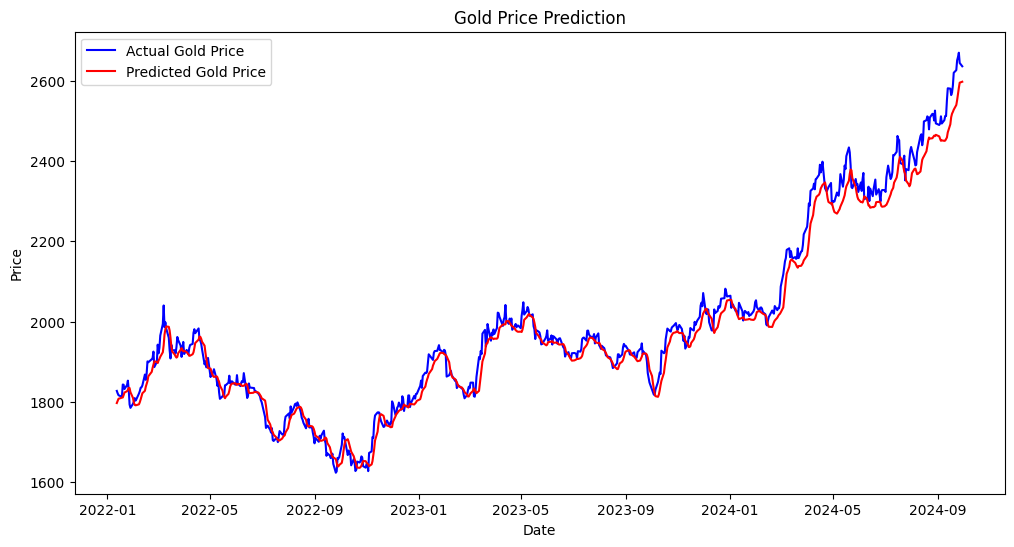

In [16]:
# Plot training history
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(seq_length, 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=25, batch_size=32)

# Test the model
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

# Plot the results
plt.figure(figsize=(12,6))
plt.plot(gold_data.index[train_size + seq_length:], gold_data['Close'][train_size + seq_length:], color='blue', label='Actual Gold Price')
plt.plot(gold_data.index[train_size + seq_length:], predictions, color='red', label='Predicted Gold Price')
plt.title('Gold Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


In [17]:
!pip install mplfinance

/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.3 MB/s eta 0:00:00


In [18]:
gold_data

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,1117.699951,184
2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,1118.099976,53
2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,1135.900024,363
2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,1133.099976,56
2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,1138.199951,54
...,...,...,...,...,...,...
2024-09-24,2636.800049,2662.300049,2625.500000,2651.199951,2651.199951,35
2024-09-25,2656.300049,2664.199951,2649.300049,2659.199951,2659.199951,175
2024-09-26,2662.300049,2669.899902,2660.800049,2669.899902,2669.899902,17216


/opt/conda/lib/python3.10/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


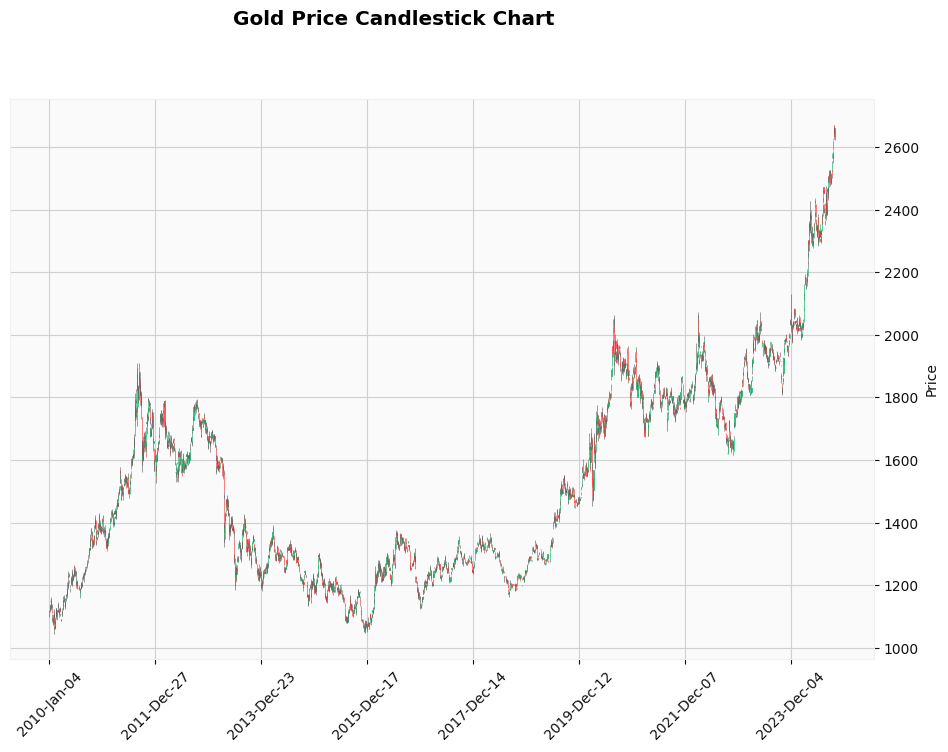

In [19]:
import pandas as pd
import mplfinance as mpf

# Check if 'Date' is already the index
if not isinstance(gold_data.index, pd.DatetimeIndex):
    # If 'Date' is a column, set it as index
    if 'Date' in gold_data.columns:
        gold_data['Date'] = pd.to_datetime(gold_data['Date'])
        gold_data.set_index('Date', inplace=True)
    else:
        raise ValueError("DataFrame doesn't have a 'Date' column or DatetimeIndex")

# Ensure the index is sorted
gold_data.sort_index(inplace=True)

# Check if we have all required columns
required_columns = ['Open', 'High', 'Low', 'Close']
if not all(col in gold_data.columns for col in required_columns):
    raise ValueError(f"DataFrame is missing one or more required columns: {required_columns}")

# Create the candlestick chart
mpf.plot(gold_data, type='candle', style='yahoo', 
         title='Gold Price Candlestick Chart',
         ylabel='Price',
         volume=False,  # Set to True if you have volume data
         figsize=(12, 8))

/tmp/ipykernel_23/1502665356.py:2: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  last_6_months = gold_data.last('6M')
/tmp/ipykernel_23/1502665356.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  last_6_months = gold_data.last('6M')


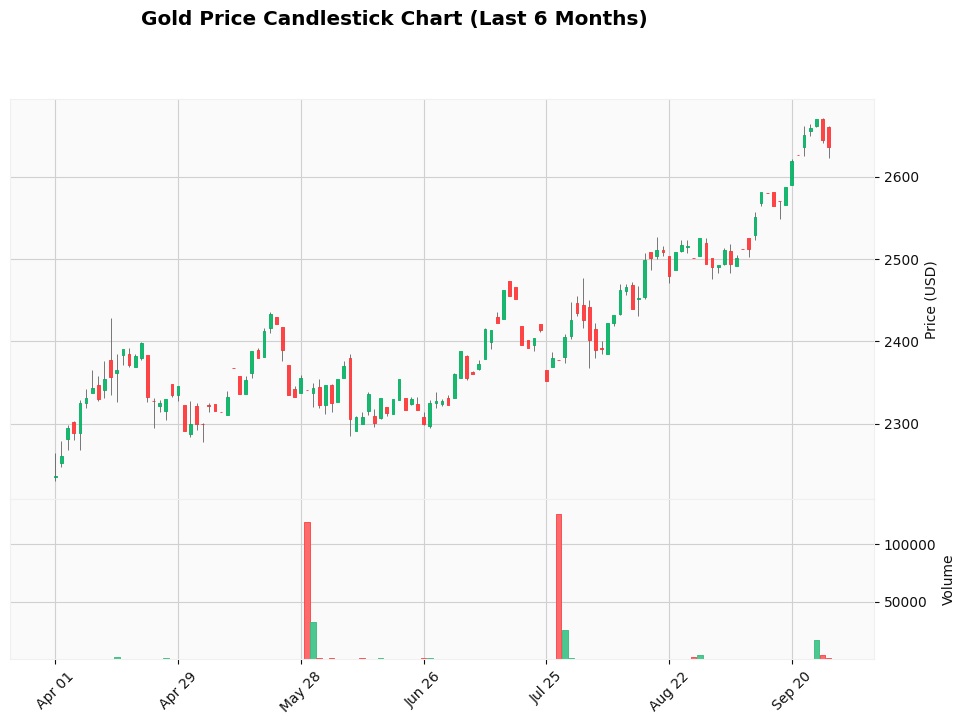

In [20]:
# Plot the last 6 months of data
last_6_months = gold_data.last('6M')
mpf.plot(last_6_months, type='candle', style='yahoo', 
         title='Gold Price Candlestick Chart (Last 6 Months)',
         ylabel='Price (USD)',
         volume=True,
         figsize=(12, 8))

/opt/conda/lib/python3.10/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


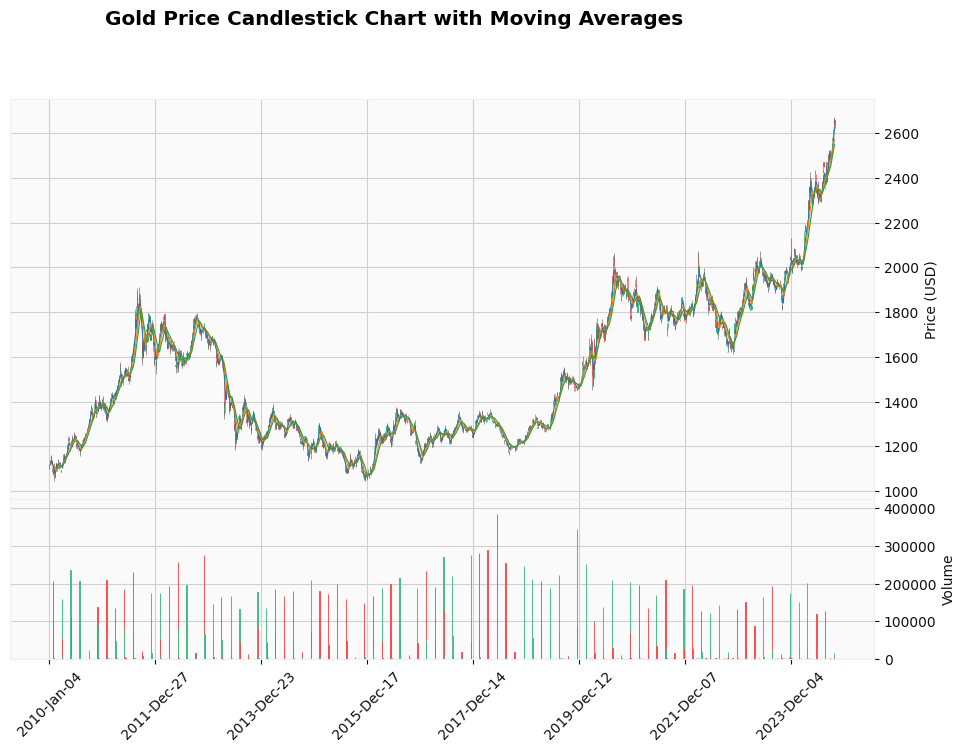

In [21]:
# Add moving averages
mpf.plot(gold_data, type='candle', style='yahoo', 
         title='Gold Price Candlestick Chart with Moving Averages',
         ylabel='Price (USD)',
         volume=True,
         figsize=(12, 8),
         mav=(10, 20, 30))  # 10, 20, and 30-day moving averages

<a id="#predict-next-10-days"></a>
<div style="background-color: #800080; padding: 10px; border-radius: 20px; text-align: center; color: white; font-size: 30px;">
  <strong>8.Predict Next 10 Days</strong>
</div>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Next 10 days gold price predictions:
[[2593.2903]
 [2576.4128]
 [2554.9106]
 [2531.432 ]
 [2507.4246]
 [2483.7007]
 [2460.7275]
 [2438.7683]
 [2417.957 ]
 [2398.3394]]


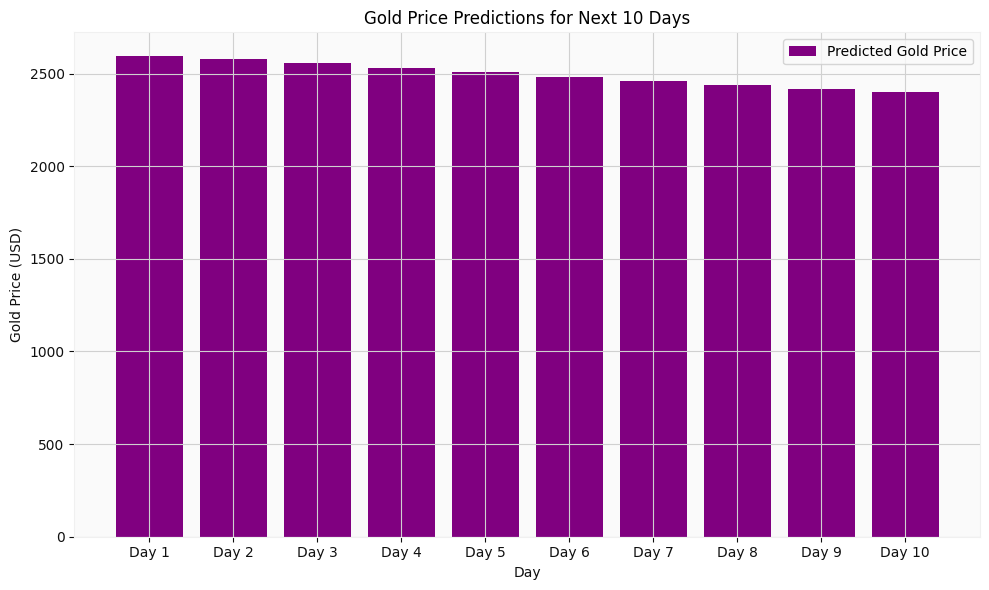

In [22]:
# Predict the next 10 days
last_sequence = scaled_data[-seq_length:]
next_10_days = []

for _ in range(10):
    prediction = model.predict(last_sequence.reshape(1, seq_length, 1))
    next_10_days.append(prediction[0,0])
    last_sequence = np.append(last_sequence[1:], prediction)

next_10_days = scaler.inverse_transform(np.array(next_10_days).reshape(-1, 1))

# Display the predictions
print("Next 10 days gold price predictions:")
print(next_10_days)


# Plotting the predicted prices as a purple bar chart
plt.figure(figsize=(10, 6))
plt.bar(range(1, 11), next_10_days.flatten(), color='purple', label='Predicted Gold Price')
plt.title('Gold Price Predictions for Next 10 Days')
plt.xlabel('Day')
plt.ylabel('Gold Price (USD)')
plt.xticks(range(1, 11), [f'Day {i}' for i in range(1, 11)])
plt.grid(True)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()


# Summary of Steps
* About Dataset: Loaded the dataset and checked the structure.
* Import Libraries & Dataset: Imported essential libraries, loaded, and inspected the dataset.
* Overview & EDA Dataset: Performed exploratory data analysis by visualizing the time series.
* Preparing Dataset: Scaled the data and created sequences suitable for LSTM input.
* Build, Train & Test Models: Built an LSTM model, trained it, and evaluated it.
* Predict Next 10 Days: Used the trained model to predict the next 10 days of values.